# 02 — DOE search space audit

Este notebook audita o **espaço de busca** e a **cobertura efetiva do delineamento experimental** usado no estudo de fairness.

A meta aqui não é rodar o pipeline R30. A ideia é responder, de forma objetiva:

- os intervalos dos hiperparâmetros estão amplos?
- os parâmetros críticos para fairness estão cobrindo as bordas relevantes?
- a cobertura do delineamento parece suficiente para o problema atual?

## O que este notebook gera

- `doe_overview.csv`
- `doe_pttype_counts.csv`
- `hyperparameter_ranges.csv`
- `edge_coverage_summary.csv`
- `critical_hyperparameters_summary.csv`
- `doe_duplicates_summary.csv`
- `doe_histograms.png`
- `doe_runorder_scatter.png`
- `doe_pairplots_critical.png`

As saídas ficam em `artifacts/doe_audit/`.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent if Path.cwd().parent != Path.cwd() else Path.cwd(),
    Path("/mnt/data"),
]

OUTPUT_ROOT = Path.cwd() / "artifacts" / "doe_audit"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

DOE_CANDIDATES = [
    "data/design/hiperparameter_design_fairness.csv",
    "hiperparameter_design_fairness.csv",
    "/mnt/data/hiperparameter_design_fairness.csv",
]

HYPERPARAM_COLS = [
    "subsample",
    "colsample_bytree",
    "colsample_bylevel",
    "learning_rate",
    "max_depth",
    "gamma",
    "n_estimators",
    "scale_pos_weight",
    "threshold",
]

CRITICAL_COLS = [
    "threshold",
    "scale_pos_weight",
    "learning_rate",
    "gamma",
    "n_estimators",
]

PTTYPE_MAP = {
    1: "factorial",
    0: "center",
    -1: "axial",
}

def resolve_path(candidates):
    for candidate in candidates:
        p = Path(candidate)
        if p.is_absolute() and p.exists():
            return p
        for root in ROOT_CANDIDATES:
            test = (root / candidate).resolve()
            if test.exists():
                return test
    raise FileNotFoundError(f"Arquivo não encontrado. Tentativas: {candidates}")

doe_path = resolve_path(DOE_CANDIDATES)
doe = pd.read_csv(doe_path, engine="python")
doe["PtTypeLabel"] = doe["PtType"].map(PTTYPE_MAP).fillna("unknown")
doe_path

PosixPath('/Users/caiotertuliano/Projects/doe_nbi_hpo_project/data/design/hiperparameter_design_fairness.csv')

In [2]:
overview = pd.DataFrame([{
    "doe_path": str(doe_path),
    "n_rows": int(len(doe)),
    "n_unique_design_rows": int(doe[HYPERPARAM_COLS].drop_duplicates().shape[0]),
    "n_duplicate_design_rows": int(len(doe) - doe[HYPERPARAM_COLS].drop_duplicates().shape[0]),
    "n_hyperparameters": int(len(HYPERPARAM_COLS)),
}])
overview.to_csv(OUTPUT_ROOT / "doe_overview.csv", index=False)

pt_counts = doe["PtTypeLabel"].value_counts().rename_axis("PtTypeLabel").reset_index(name="count")
pt_counts.to_csv(OUTPUT_ROOT / "doe_pttype_counts.csv", index=False)

overview, pt_counts

(                                            doe_path  n_rows  \
 0  /Users/caiotertuliano/Projects/doe_nbi_hpo_pro...     152   
 
    n_unique_design_rows  n_duplicate_design_rows  n_hyperparameters  
 0                   147                        5                  9  ,
   PtTypeLabel  count
 0   factorial    128
 1       axial     18
 2      center      6)

In [3]:
range_rows = []
for col in HYPERPARAM_COLS:
    s = pd.to_numeric(doe[col], errors="coerce")
    unique_vals = sorted(s.dropna().unique().tolist())
    center = float(np.median(unique_vals)) if unique_vals else np.nan
    range_rows.append({
        "hyperparameter": col,
        "min": float(s.min()),
        "max": float(s.max()),
        "mean": float(s.mean()),
        "median": float(s.median()),
        "n_unique_values": int(s.nunique()),
        "unique_values_preview": ", ".join([str(v) for v in unique_vals[:10]]),
    })

ranges_df = pd.DataFrame(range_rows).sort_values("hyperparameter").reset_index(drop=True)
ranges_df.to_csv(OUTPUT_ROOT / "hyperparameter_ranges.csv", index=False)
ranges_df

,hyperparameter,min,max,mean,median,n_unique_values,unique_values_preview
0,colsample_bylevel,0.05,1.0,0.525,0.525,3,"0.05, 0.525, 1.0"
1,colsample_bytree,0.05,1.0,0.525,0.525,3,"0.05, 0.525, 1.0"
2,gamma,0.05,5.0,2.525,2.525,3,"0.05, 2.525, 5.0"
3,learning_rate,0.01,0.3,0.155,0.155,3,"0.01, 0.155, 0.3"
4,max_depth,3.00,18.0,10.500,10.500,3,"3.0, 10.5, 18.0"
5,n_estimators,50.00,700.0,375.000,375.000,3,"50, 375, 700"
6,scale_pos_weight,1.00,30.0,15.500,15.500,3,"1.0, 15.5, 30.0"
7,subsample,0.05,1.0,0.525,0.525,3,"0.05, 0.525, 1.0"
8,threshold,0.10,0.9,0.500,0.500,3,"0.1, 0.5, 0.9"


In [4]:
edge_rows = []
for col in HYPERPARAM_COLS:
    s = pd.to_numeric(doe[col], errors="coerce")
    smin = float(s.min())
    smax = float(s.max())
    edge_rows.append({
        "hyperparameter": col,
        "count_at_min": int((s == smin).sum()),
        "count_at_max": int((s == smax).sum()),
        "pct_at_min": float((s == smin).mean()),
        "pct_at_max": float((s == smax).mean()),
        "p10": float(s.quantile(0.10)),
        "p90": float(s.quantile(0.90)),
    })

edge_df = pd.DataFrame(edge_rows).sort_values("hyperparameter").reset_index(drop=True)
edge_df.to_csv(OUTPUT_ROOT / "edge_coverage_summary.csv", index=False)

critical_df = edge_df.loc[edge_df["hyperparameter"].isin(CRITICAL_COLS)].reset_index(drop=True)
critical_df.to_csv(OUTPUT_ROOT / "critical_hyperparameters_summary.csv", index=False)

duplicates_df = (
    doe.groupby(HYPERPARAM_COLS)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
duplicates_df.to_csv(OUTPUT_ROOT / "doe_duplicates_summary.csv", index=False)

critical_df

,hyperparameter,count_at_min,count_at_max,pct_at_min,pct_at_max,p10,p90
0,gamma,65,65,0.427632,0.427632,0.05,5.0
1,learning_rate,65,65,0.427632,0.427632,0.01,0.3
2,n_estimators,65,65,0.427632,0.427632,50.00,700.0
3,scale_pos_weight,65,65,0.427632,0.427632,1.00,30.0
4,threshold,65,65,0.427632,0.427632,0.10,0.9


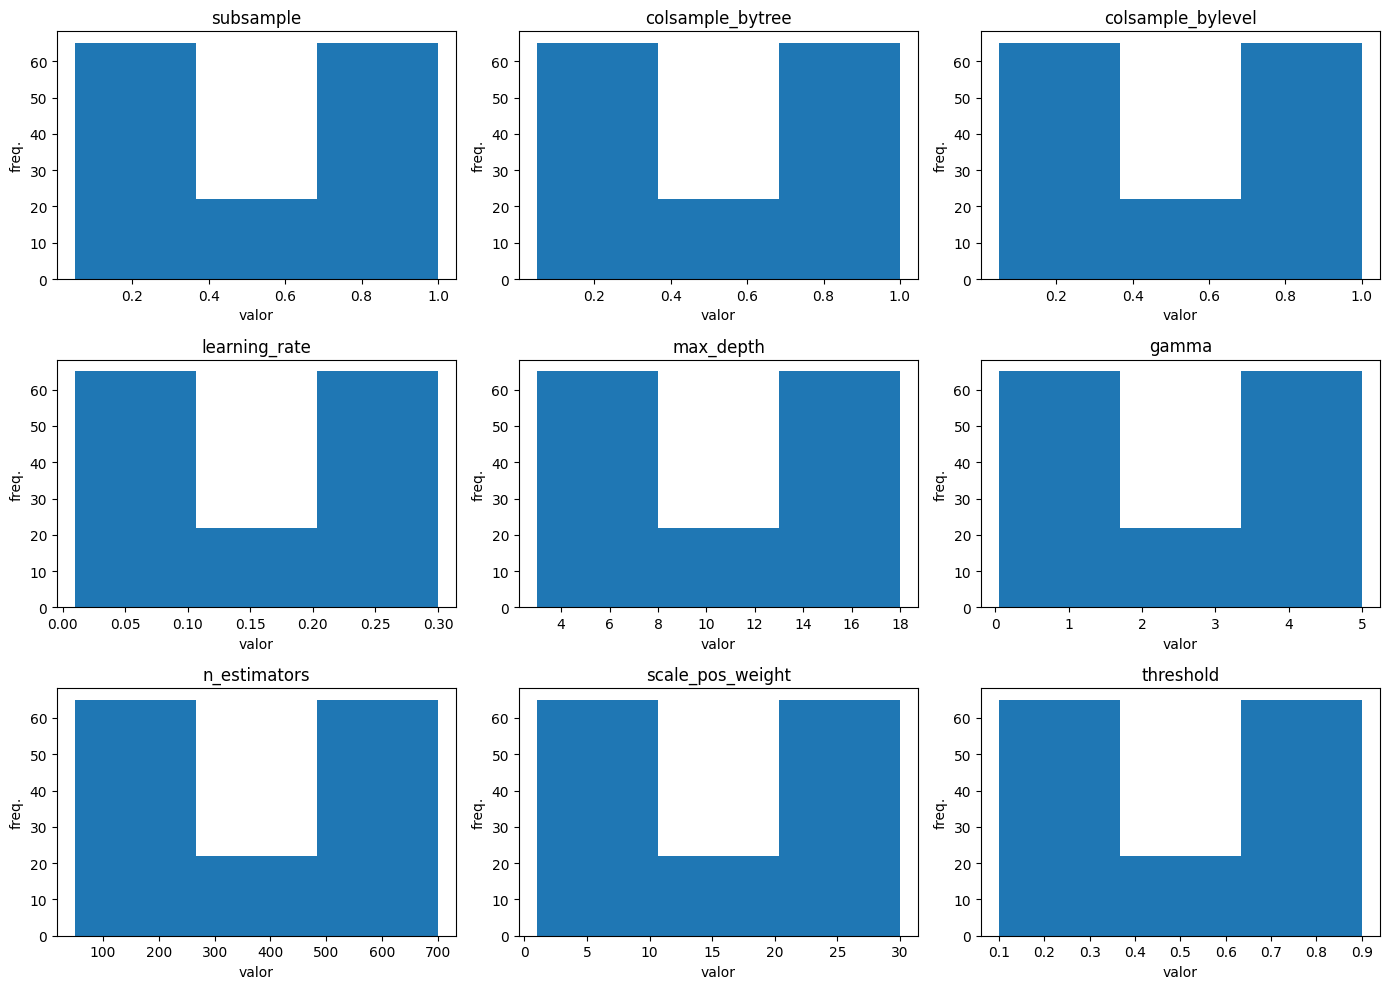

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, HYPERPARAM_COLS):
    ax.hist(pd.to_numeric(doe[col], errors="coerce"), bins=min(20, doe[col].nunique()))
    ax.set_title(col)
    ax.set_xlabel("valor")
    ax.set_ylabel("freq.")

fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "doe_histograms.png", dpi=180, bbox_inches="tight")
plt.show()

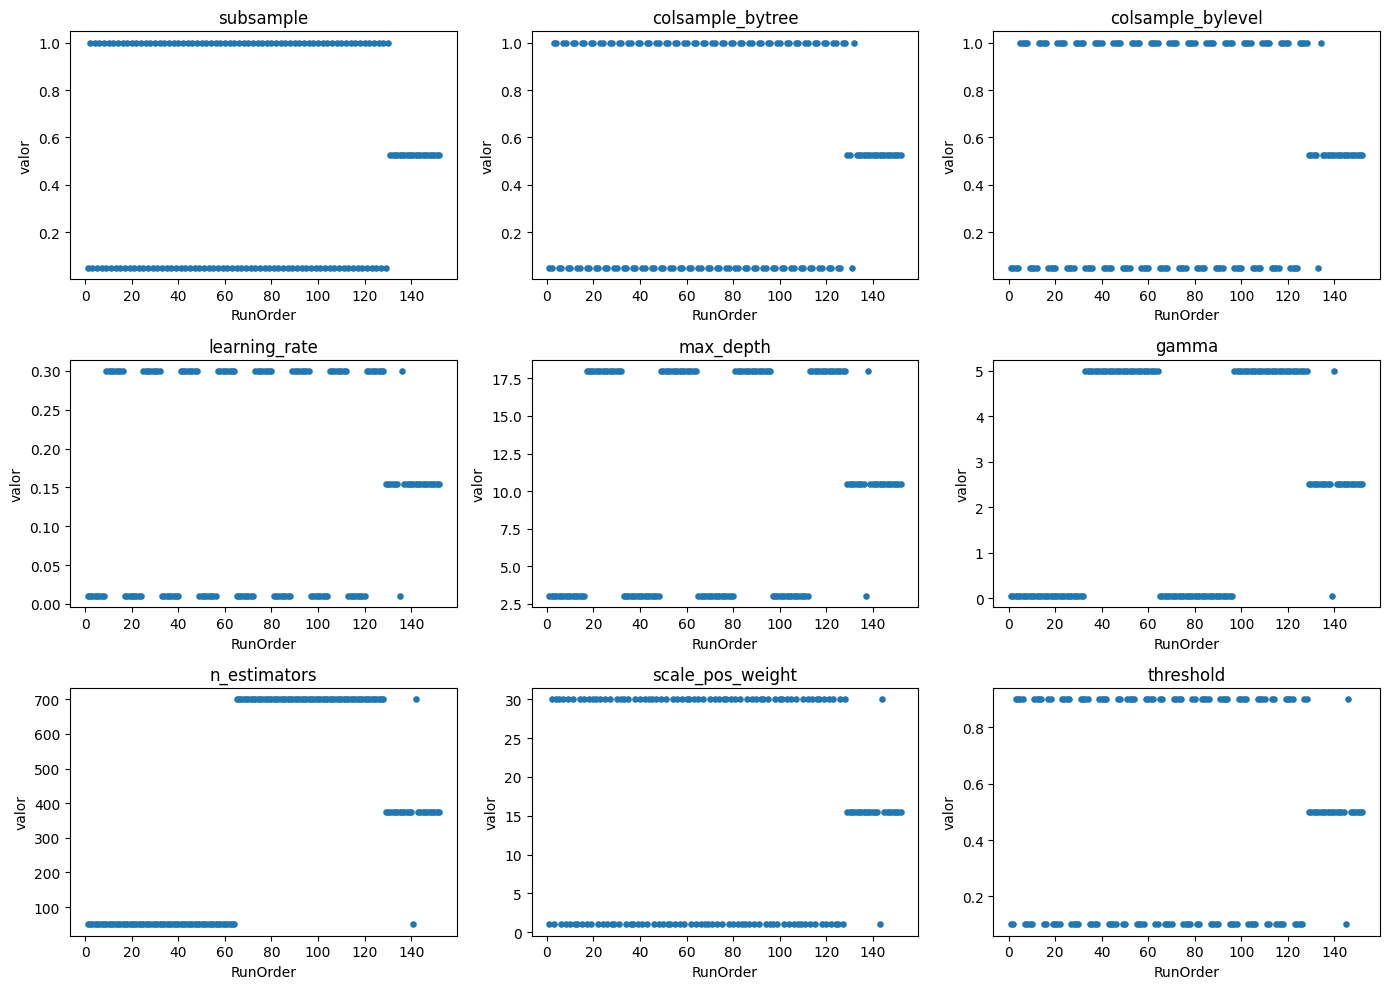

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, HYPERPARAM_COLS):
    ax.scatter(doe["RunOrder"], pd.to_numeric(doe[col], errors="coerce"), s=14)
    ax.set_title(col)
    ax.set_xlabel("RunOrder")
    ax.set_ylabel("valor")

fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "doe_runorder_scatter.png", dpi=180, bbox_inches="tight")
plt.show()

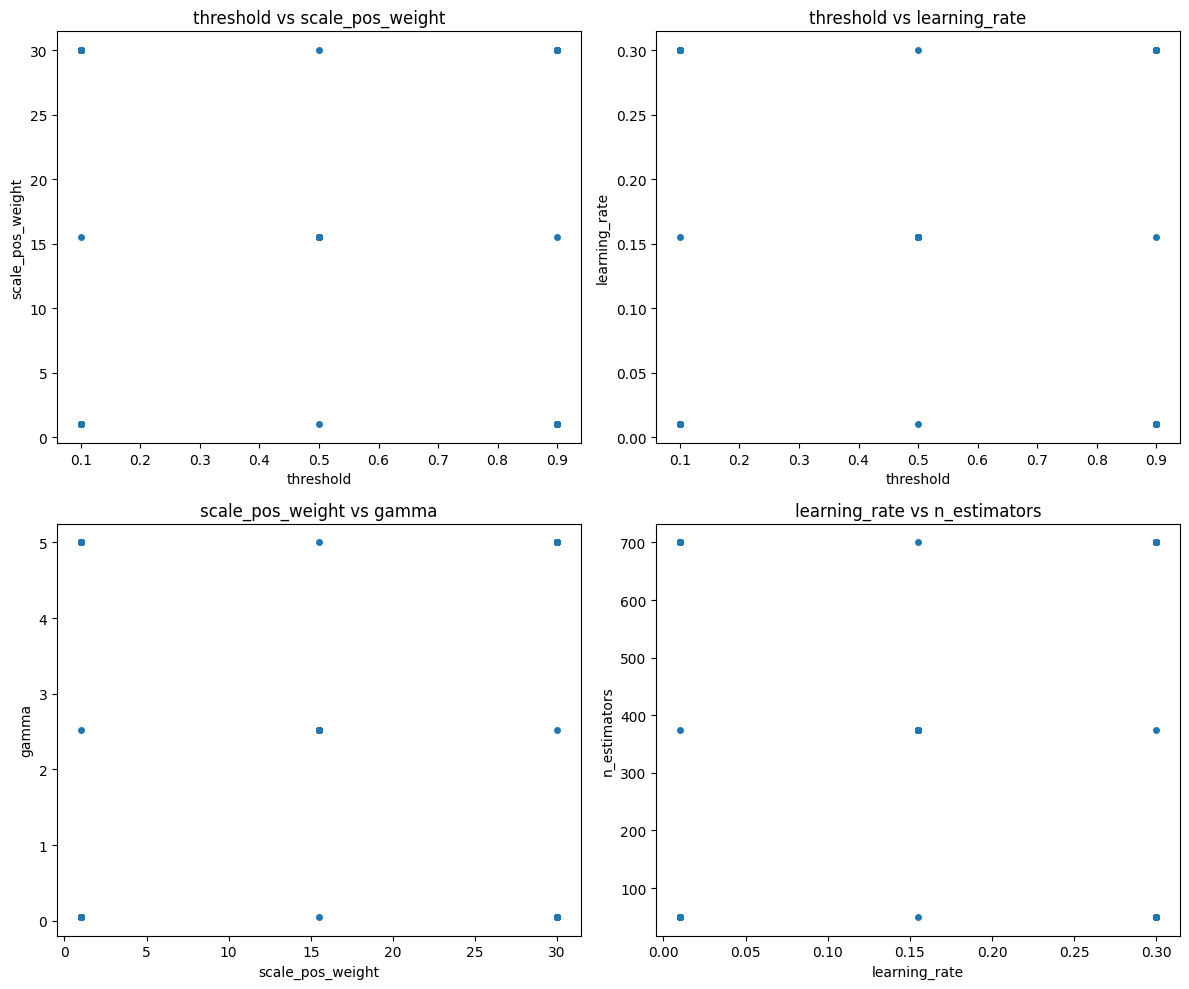

In [7]:
pairs = [
    ("threshold", "scale_pos_weight"),
    ("threshold", "learning_rate"),
    ("scale_pos_weight", "gamma"),
    ("learning_rate", "n_estimators"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (xcol, ycol) in zip(axes, pairs):
    ax.scatter(pd.to_numeric(doe[xcol], errors="coerce"), pd.to_numeric(doe[ycol], errors="coerce"), s=16)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{xcol} vs {ycol}")

fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "doe_pairplots_critical.png", dpi=180, bbox_inches="tight")
plt.show()

## Como interpretar rapidamente

1. Se `threshold` e `scale_pos_weight` já cobrem extremos amplos, o problema provavelmente **não é intervalo estreito nominal**.
2. Se a cobertura nas bordas está presente, mas o delineamento continua esparso em 9 dimensões, a limitação pode ser de **resolução efetiva**, não de range.
3. Esse notebook serve para documentar a suficiência — ou insuficiência — da cobertura do espaço de busca antes da bateria R30.